# Exploratory Data Analysis (EDA) - Two Moons Dataset

This notebook performs an exploratory data analysis on the synthetic Two Moons dataset generated using `sklearn.datasets.make_moons`. The goal is to understand the data's structure, distributions, and the non-linear relationship between the features and the target class.

**Dataset Information:**

This is a synthetic dataset designed for binary classification tasks where the data points form two interleaving half-circles (moons). It's often used to test classification algorithms that can handle non-linear decision boundaries.

**Features:**
1.  **x1**: First feature (continuous)
2.  **x2**: Second feature (continuous)

**Target:**
3.  **class**: Class label (0 or 1) (integer)

## Import Required Libraries
Import pandas for data manipulation, matplotlib and seaborn for visualization, numpy for numerical operations, and `make_moons` from scikit-learn.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons

# Set plot style
sns.set(style="whitegrid")

## Generate the Dataset
Define and use the `generate_two_moons` function to create the dataset with 1500 samples and moderate noise (0.25).

In [2]:
def generate_two_moons():
    """Generates the Two Moons dataset."""
    dataset_name = "two_moons"
    print(f"Processing dataset: {dataset_name}")
    # Generate 1500 samples, with moderate noise
    X, y = make_moons(n_samples=1500, noise=0.25, random_state=42) 
    two_moons_df = pd.DataFrame(np.c_[X, y], columns=['x1', 'x2', 'class'])
    # Ensure class is integer type for clarity in plots
    two_moons_df['class'] = two_moons_df['class'].astype(int)
    print("Dataset generated successfully.")
    return two_moons_df

# Generate the data
df_moons = generate_two_moons()

Processing dataset: two_moons
Dataset generated successfully.


## Initial Data Inspection
Display the first few rows (`head()`), summary information (`info()`), and descriptive statistics (`describe()`) of the DataFrame.

In [3]:
if df_moons is not None:
    print("First 5 rows of the dataset:")
    print(df_moons.head())

First 5 rows of the dataset:
         x1        x2  class
0  1.006769 -0.500118      1
1  1.831027  0.214122      1
2  0.146651  1.151115      0
3 -0.194047  1.268410      0
4 -0.688850  0.769947      0


In [4]:
if df_moons is not None:
    print("\nDataset Information:")
    df_moons.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      1500 non-null   float64
 1   x2      1500 non-null   float64
 2   class   1500 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 35.3 KB


In [5]:
if df_moons is not None:
    print("\nDescriptive Statistics:")
    print(df_moons.describe())


Descriptive Statistics:
                x1           x2        class
count  1500.000000  1500.000000  1500.000000
mean      0.505002     0.259272     0.500000
std       0.899804     0.561523     0.500167
min      -1.583726    -1.316127     0.000000
25%      -0.099542    -0.182027     0.000000
50%       0.478715     0.265616     0.500000
75%       1.159149     0.702168     1.000000
max       2.689645     1.687472     1.000000


## Check for Missing Values and Duplicates
Since this is a synthetically generated dataset using `make_moons`, we don't expect missing values or duplicates, but it's good practice to verify.

In [6]:
if df_moons is not None:
    print("\n--- Data Quality Check ---")
    missing_count = df_moons.isnull().sum().sum()
    duplicate_count = df_moons.duplicated().sum()
    print(f"Missing values: {missing_count}")
    print(f"Duplicate rows: {duplicate_count}")
    print("-------------------------")


--- Data Quality Check ---
Missing values: 0
Duplicate rows: 0
-------------------------


## Analyze Target Variable Distribution
Analyze the distribution of the 'class' variable. `make_moons` generates a balanced dataset by default.

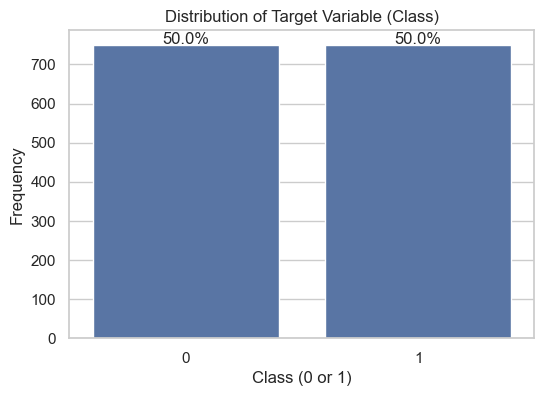


Class Distribution:
class
1    0.5
0    0.5
Name: proportion, dtype: float64

The dataset is perfectly balanced as expected.


In [7]:
if df_moons is not None:
    plt.figure(figsize=(6, 4))
    sns.countplot(x='class', data=df_moons)
    plt.title('Distribution of Target Variable (Class)')
    plt.xlabel('Class (0 or 1)')
    plt.ylabel('Frequency')
    
    # Calculate and display percentages
    total = len(df_moons)
    ax = plt.gca()
    for p in ax.patches:
        height = p.get_height()
        ax.text(p.get_x() + p.get_width()/2.,
                height + 3, 
                f'{height/total:.1%}',
                ha="center") 
    
    plt.show()

    print("\nClass Distribution:")
    print(df_moons['class'].value_counts(normalize=True))
    print("\nThe dataset is perfectly balanced as expected.")

## Analyze Feature Distributions
Visualize the distribution of the features 'x1' and 'x2' using histograms or density plots.


--- Feature Distributions ---


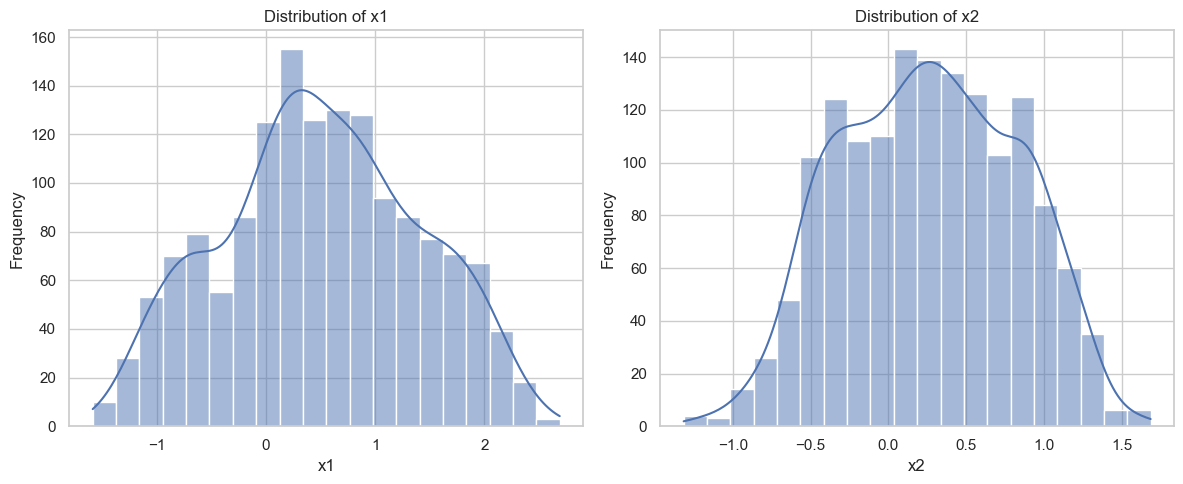

In [8]:
if df_moons is not None:
    features = ['x1', 'x2']
    
    print("\n--- Feature Distributions ---")
    plt.figure(figsize=(12, 5))
    
    for i, feature in enumerate(features):
        plt.subplot(1, 2, i + 1)
        sns.histplot(df_moons[feature], kde=True)
        plt.title(f'Distribution of {feature}')
        plt.xlabel(feature)
        plt.ylabel('Frequency')
        
    plt.tight_layout()
    plt.show()

## Visualize Feature Relationships (Scatter Plot)
Create a scatter plot of 'x1' vs 'x2', colored by the 'class' variable. This is the most informative plot for the Two Moons dataset, showing the characteristic non-linear separation.


--- Scatter Plot (x1 vs x2, Colored by Class) ---


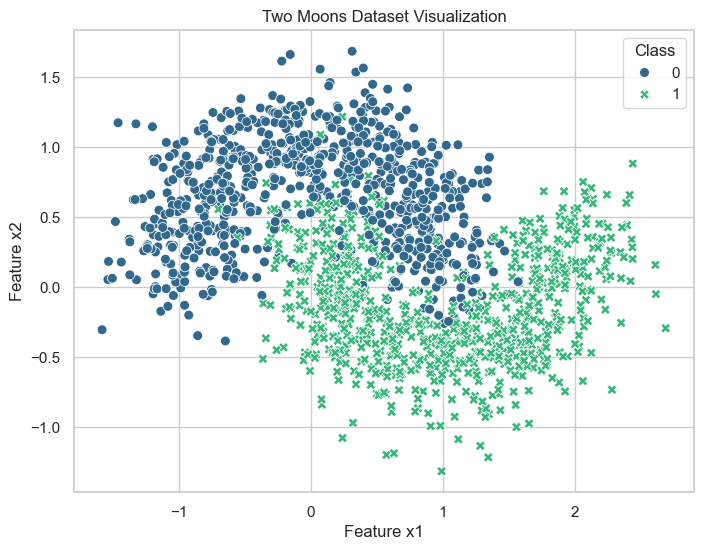

In [9]:
if df_moons is not None:
    print("\n--- Scatter Plot (x1 vs x2, Colored by Class) ---")
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x='x1', y='x2', hue='class', data=df_moons, palette='viridis', style='class', s=50)
    plt.title('Two Moons Dataset Visualization')
    plt.xlabel('Feature x1')
    plt.ylabel('Feature x2')
    plt.legend(title='Class')
    plt.show()

## Analyze Feature Differences Between Classes
Use box plots to compare the distribution of each feature ('x1', 'x2') across the two target classes. While the scatter plot is more revealing for this dataset, box plots can still show differences in central tendency and spread.


--- Feature Distributions by Class (Box Plots) ---


/tmp/ipykernel_548968/4276631385.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='class', y=feature, data=df_moons, palette='viridis')
/tmp/ipykernel_548968/4276631385.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='class', y=feature, data=df_moons, palette='viridis')


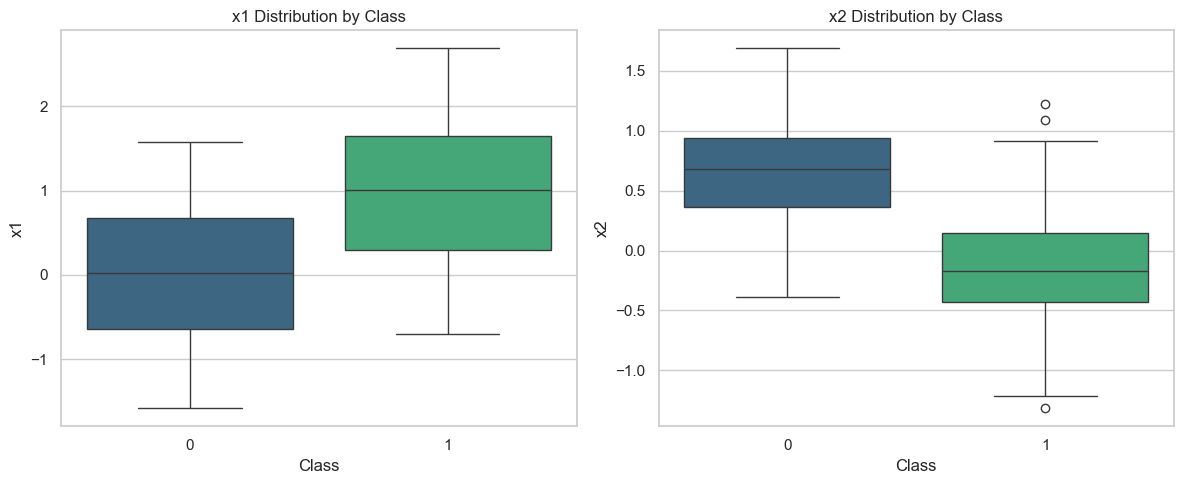

In [10]:
if df_moons is not None:
    features = ['x1', 'x2']
    
    print("\n--- Feature Distributions by Class (Box Plots) ---")
    plt.figure(figsize=(12, 5))
    
    for i, feature in enumerate(features):
        plt.subplot(1, 2, i + 1)
        sns.boxplot(x='class', y=feature, data=df_moons, palette='viridis')
        plt.title(f'{feature} Distribution by Class')
        plt.xlabel('Class')
        plt.ylabel(feature)
        
    plt.tight_layout()
    plt.show()

## EDA Summary

- **Data Generation & Quality:** The dataset was generated successfully with 1500 samples and noise=0.25. As expected, there are no missing values or duplicates.
- **Target Variable:** The target variable ('class') is binary (0 or 1) and perfectly balanced (50% for each class).
- **Feature Distributions:** The individual distributions of 'x1' and 'x2' don't reveal the underlying structure on their own. 'x1' appears roughly bimodal, while 'x2' is somewhat skewed.
- **Feature Relationships & Class Separation:**
    - The scatter plot is the key visualization, clearly showing the two interleaving moon shapes.
    - The classes are not linearly separable; a non-linear decision boundary is required for accurate classification.
    - The noise introduces some overlap between the classes, making perfect separation challenging.
    - Box plots show some differences in the distributions of 'x1' and 'x2' between the classes, but they don't capture the non-linear relationship evident in the scatter plot.

**Next Steps:** This dataset is well-suited for evaluating classification models capable of learning non-linear boundaries, such as Kernel SVM, Neural Networks, or Quantum Classifiers.